### 전처리
- pdf 문서에서 텍스트와 이미지를 분리하여 추출하고 OpenAI를 이용해 이미지를 텍스트로 요약

In [1]:
!pip install PyMuPDF

   ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
   ---- ----------------------------------- 2.4/19.2 MB 16.8 MB/s eta 0:00:02
   --------------- ------------------------ 7.6/19.2 MB 18.1 MB/s eta 0:00:01
   ---------------------------------------  19.1/19.2 MB 32.7 MB/s eta 0:00:01
   ---------------------------------------- 19.2/19.2 MB 30.4 MB/s  0:00:00


In [3]:
import os
import fitz  # PyMuPDF
import requests
import base64
from dotenv import load_dotenv
from openai import OpenAI
load_dotenv(override=True)
client = OpenAI()

In [4]:
# https://arxiv.org/pdf/1706.03762.pdf
pdf_url = 'https://arxiv.org/pdf/1706.03762.pdf'
pdf_path = 'sample_paper.pdf'
if not os.path.exists(pdf_path):
    response = requests.get(pdf_url)
    with open(pdf_path, 'wb') as f:
        f.write(response.content)
    print('다운로드 완료')
else:
    print(f'{pdf_path} 가 존재합니다.')

다운로드 완료


### PDF에서 텍스트와 이미지 추출

In [7]:
doc = fitz.open(pdf_path)
texts = []
images = []
output_img_dir = 'extracted_images'
os.makedirs(output_img_dir, exist_ok=True)
for page_num in range(len(doc)):
    page = doc.load_page(page_num)
    # 텍스트 추출
    text = page.get_text()
    if text.strip():
        texts.append({'page':page_num,'content':text})
    # 이미지 추출
    image_list = page.get_images(full=True)
    for image_index, img in  enumerate(image_list):
        xref = img[0]
        base_image =  doc.extract_image(xref)
        image_bytes = base_image['image']
        image_ext = base_image['ext']

        image_filename = f'page{page_num}_img{image_index+1}.{image_ext}'
        image_filepath = os.path.join(output_img_dir,image_filename)
        
        with open(image_filepath,'wb') as f:
            f.write(image_bytes)
        images.append({
            'page':page_num+1,
            'filename':image_filepath,
            'bytes':image_bytes,
            'ext':image_ext
        })
print(f'추출완료 : 텍스트 : {len(texts)}페이지, 이미지:{len(images)}개')        

추출완료 : 텍스트 : 15페이지, 이미지:3개


### 이미지 요약 gpt-5.4-nano
- 이미지에 대한 상세 설명을 텍스트로 요약

In [8]:
def encode_image(image_bytes):
    return base64.b64encode(image_bytes).decode('utf-8')

image_summaries = []
for img_meta in images:
    base64_image = encode_image(img_meta['bytes'])
    ext = img_meta['ext']
    if ext.lower() =='jb2':
        ext = 'jpeg'
    mime_type = f'image/{ext}' if ext.lower() != "jpg" else 'image/jpeg'
    try:
        response = client.chat.completions.create(
            model = 'gpt-5.4-nano',
            messages=[
                {'role':'user', 
                 'content': [
                     {'type':'text', 'text':'이 이미지에 대한 상세한 설명을 작성해 주세요'},
                     {'type':'image_url', 'image_url':{
                         'url':f'data:{mime_type};base64,{base64_image}'
                         }
                      }
                 ]
                 }
            ],
            max_completion_tokens=300
        )
        summary = response.choices[0].message.content
        image_summaries.append({
            'filename':img_meta['filename'],
            'summary' : summary
        })
        print(f"[{img_meta['filename']}] 요약완료")
    except Exception as e:
        print(f"[{img_meta['filename']}] 요약실패 : {e}")

[extracted_images\page2_img1.png] 요약완료
[extracted_images\page3_img1.png] 요약완료
[extracted_images\page3_img2.png] 요약완료


In [16]:
import matplotlib.pyplot as plt
from PIL import Image
def show_img_surmmarize(index):
    img = Image.open(image_summaries[index]['filename'])
    plt.imshow(img)
    plt.axis('off')
    plt.show()    
    print(image_summaries[index]['summary'])

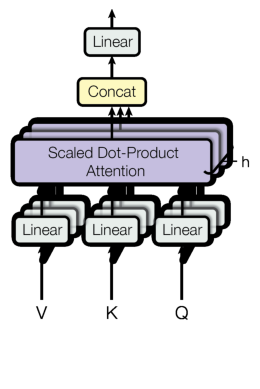

이 이미지는 신경망(특히 Transformer 계열)에서 **Scaled Dot-Product Attention**이 어떻게 여러 입력(질의/키/값)을 처리하는지 흐름도를 도식화한 그래픽입니다.

## 전체 구조(위에서 아래로)
1. **상단 화살표**
   - 위쪽에서 아래로 흐르는 흐름(큰 검은 화살표)이 존재합니다.

2. **Linear 블록(첫 번째)**
   - 중앙 상단의 흰색 라운드 사각형에 **“Linear”**라고 적혀 있습니다.
   - 이 블록을 통과하면서 입력이 선형 변환(투영)됩니다.

3. **Concat 블록**
   - 그 아래에 노란색 라운드 사각형 **“Concat”**이 있으며,
   - 위에서 여러 경로로 생성된 결과를 **하나로 합치는(concatenate)** 역할을 나타냅니다.

4. **Scaled Dot-Product Attention 블록(가운데)**
   - Concat 아래의 큰 보라색 라운드 사각형에는 **“Scaled Dot-Product Attention”**이라고 적혀 있습니다.
   - 우측에는 일부 **“h”**(헤드 수를 의미하는 표기처럼 보임)가 보이며,
   - 이는 여러 attention head를 사용한다는 맥락을 시사합니다.

## 하단의


In [19]:
show_img_surmmarize(2)